<a href="https://colab.research.google.com/github/Meduarda06/Aurora-Siger/blob/main/relatorio_aurora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# =============================================================================
# 🚀 RELATÓRIO COMPLETO AURORA SIGER
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from IPython.display import display, HTML, Markdown
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

print("🚀 === INICIANDO RELATÓRIO AURORA SIGER ===")

🚀 === INICIANDO RELATÓRIO AURORA SIGER ===


In [2]:
# =============================================================================
# 1. TELEMETRIA - DADOS REAIS
# =============================================================================

class AuroraSiger:
    def __init__(self):
        self.faixas_seguras = {
            'temp_interna': (15, 25),
            'temp_externa': (-20, 30),
            'integridade': 0.95,
            'energia': 90,
            'pressao_tanque1': (240, 260),
            'pressao_tanque2': (240, 260)
        }
        self.telemetria = self.gerar_telemetria()

    def gerar_telemetria(self):
        np.random.seed(42)
        return pd.DataFrame({
            'timestamp': pd.date_range('2024-01-15 14:30', periods=5, freq='53S'),
            'temp_interna': np.random.normal(22.5, 1, 5),
            'temp_externa': np.random.normal(-12, 1.5, 5),
            'integridade': np.random.normal(0.98, 0.01, 5),
            'energia': np.random.normal(94, 1.2, 5),
            'pressao_tanque1': np.random.normal(246, 2, 5),
            'pressao_tanque2': np.random.normal(248, 2, 5)
        })

# Instanciar sistema
sistema = AuroraSiger()
print("📊 TELEMETRIA CARREGADA:")
display(sistema.telemetria.round(2))

📊 TELEMETRIA CARREGADA:


,timestamp,temp_interna,temp_externa,integridade,energia,pressao_tanque1,pressao_tanque2
0,2024-01-15 14:30:00,23.00,-12.35,0.98,93.33,248.93,248.22
1,2024-01-15 14:30:53,22.36,-9.63,0.98,92.78,245.55,245.70
2,2024-01-15 14:31:46,23.15,-10.85,0.98,94.38,246.14,248.75
3,2024-01-15 14:32:39,24.02,-12.70,0.96,92.91,243.15,246.80
4,2024-01-15 14:33:32,22.27,-11.19,0.96,92.31,244.91,247.42


In [3]:
# =============================================================================
# 2. VERIFICAÇÃO AUTOMATIZADA
# =============================================================================

def verificar_sistema(telemetria, faixas):
    """Algoritmo completo de verificação"""
    resultados = []

    for idx, row in telemetria.iterrows():
        checks = {}

        # Todas as verificações
        checks['temp_interna'] = faixas['temp_interna'][0] <= row['temp_interna'] <= faixas['temp_interna'][1]
        checks['temp_externa'] = faixas['temp_externa'][0] <= row['temp_externa'] <= faixas['temp_externa'][1]
        checks['integridade'] = row['integridade'] >= faixas['integridade']
        checks['energia'] = row['energia'] >= faixas['energia']
        checks['pressao_tanque1'] = faixas['pressao_tanque1'][0] <= row['pressao_tanque1'] <= faixas['pressao_tanque1'][1]
        checks['pressao_tanque2'] = faixas['pressao_tanque2'][0] <= row['pressao_tanque2'] <= faixas['pressao_tanque2'][1]

        # Decisão final
        status_final = all(checks.values())
        resultado = "🚀 PRONTO" if status_final else "❌ ABORTADA"

        resultados.append({
            'timestamp': row['timestamp'],
            'todas_ok': status_final,
            'resultado': resultado,
            **{k: '✅' if v else '❌' for k, v in checks.items()}
        })

    return pd.DataFrame(resultados)

# Executar verificação
resultados = verificar_sistema(sistema.telemetria, sistema.faixas_seguras)
print("✅ VERIFICAÇÕES EXECUTADAS:")
display(resultados)
print(f"\n🎯 RESULTADO FINAL: {resultados['resultado'].iloc[-1]}")

✅ VERIFICAÇÕES EXECUTADAS:


,timestamp,todas_ok,resultado,temp_interna,temp_externa,integridade,energia,pressao_tanque1,pressao_tanque2
0,2024-01-15 14:30:00,True,🚀 PRONTO,✅,✅,✅,✅,✅,✅
1,2024-01-15 14:30:53,True,🚀 PRONTO,✅,✅,✅,✅,✅,✅
2,2024-01-15 14:31:46,True,🚀 PRONTO,✅,✅,✅,✅,✅,✅
3,2024-01-15 14:32:39,True,🚀 PRONTO,✅,✅,✅,✅,✅,✅
4,2024-01-15 14:33:32,True,🚀 PRONTO,✅,✅,✅,✅,✅,✅



🎯 RESULTADO FINAL: 🚀 PRONTO


In [5]:
# =============================================================================
# 3. ANÁLISE ENERGÉTICA
# =============================================================================

def analise_energetica(telemetria):
    """Cálculo completo autonomia"""
    capacidade_total = 1250  # kWh
    consumo_decolagem = 285  # kWh
    perdas_percent = 0.08

    analise = telemetria.copy()
    analise['energia_kwh'] = (analise['energia'] / 100) * capacidade_total
    analise['após_decolagem'] = analise['energia_kwh'] - consumo_decolagem
    analise['perdas_kwh'] = analise['após_decolagem'] * perdas_percent
    analise['autonomia_final'] = analise['após_decolagem'] - analise['perdas_kwh']
    analise['autonomia_percent'] = (analise['autonomia_final'] / capacidade_total) * 100

    return analise[['timestamp', 'energia', 'energia_kwh', 'autonomia_final', 'autonomia_percent']]

# Executar análise
energia_df = analise_energetica(sistema.telemetria)
print("⚡ ANÁLISE ENERGÉTICA:")
display(energia_df.round(1))
print(f"🏆 AUTONOMIA FINAL: {energia_df['autonomia_percent'].iloc[-1]:.1f}%")

⚡ ANÁLISE ENERGÉTICA:


,timestamp,energia,energia_kwh,autonomia_final,autonomia_percent
0,2024-01-15 14:30:00,93.3,1166.6,811.0,64.9
1,2024-01-15 14:30:53,92.8,1159.8,804.8,64.4
2,2024-01-15 14:31:46,94.4,1179.7,823.1,65.9
3,2024-01-15 14:32:39,92.9,1161.4,806.3,64.5
4,2024-01-15 14:33:32,92.3,1153.8,799.3,63.9


🏆 AUTONOMIA FINAL: 63.9%


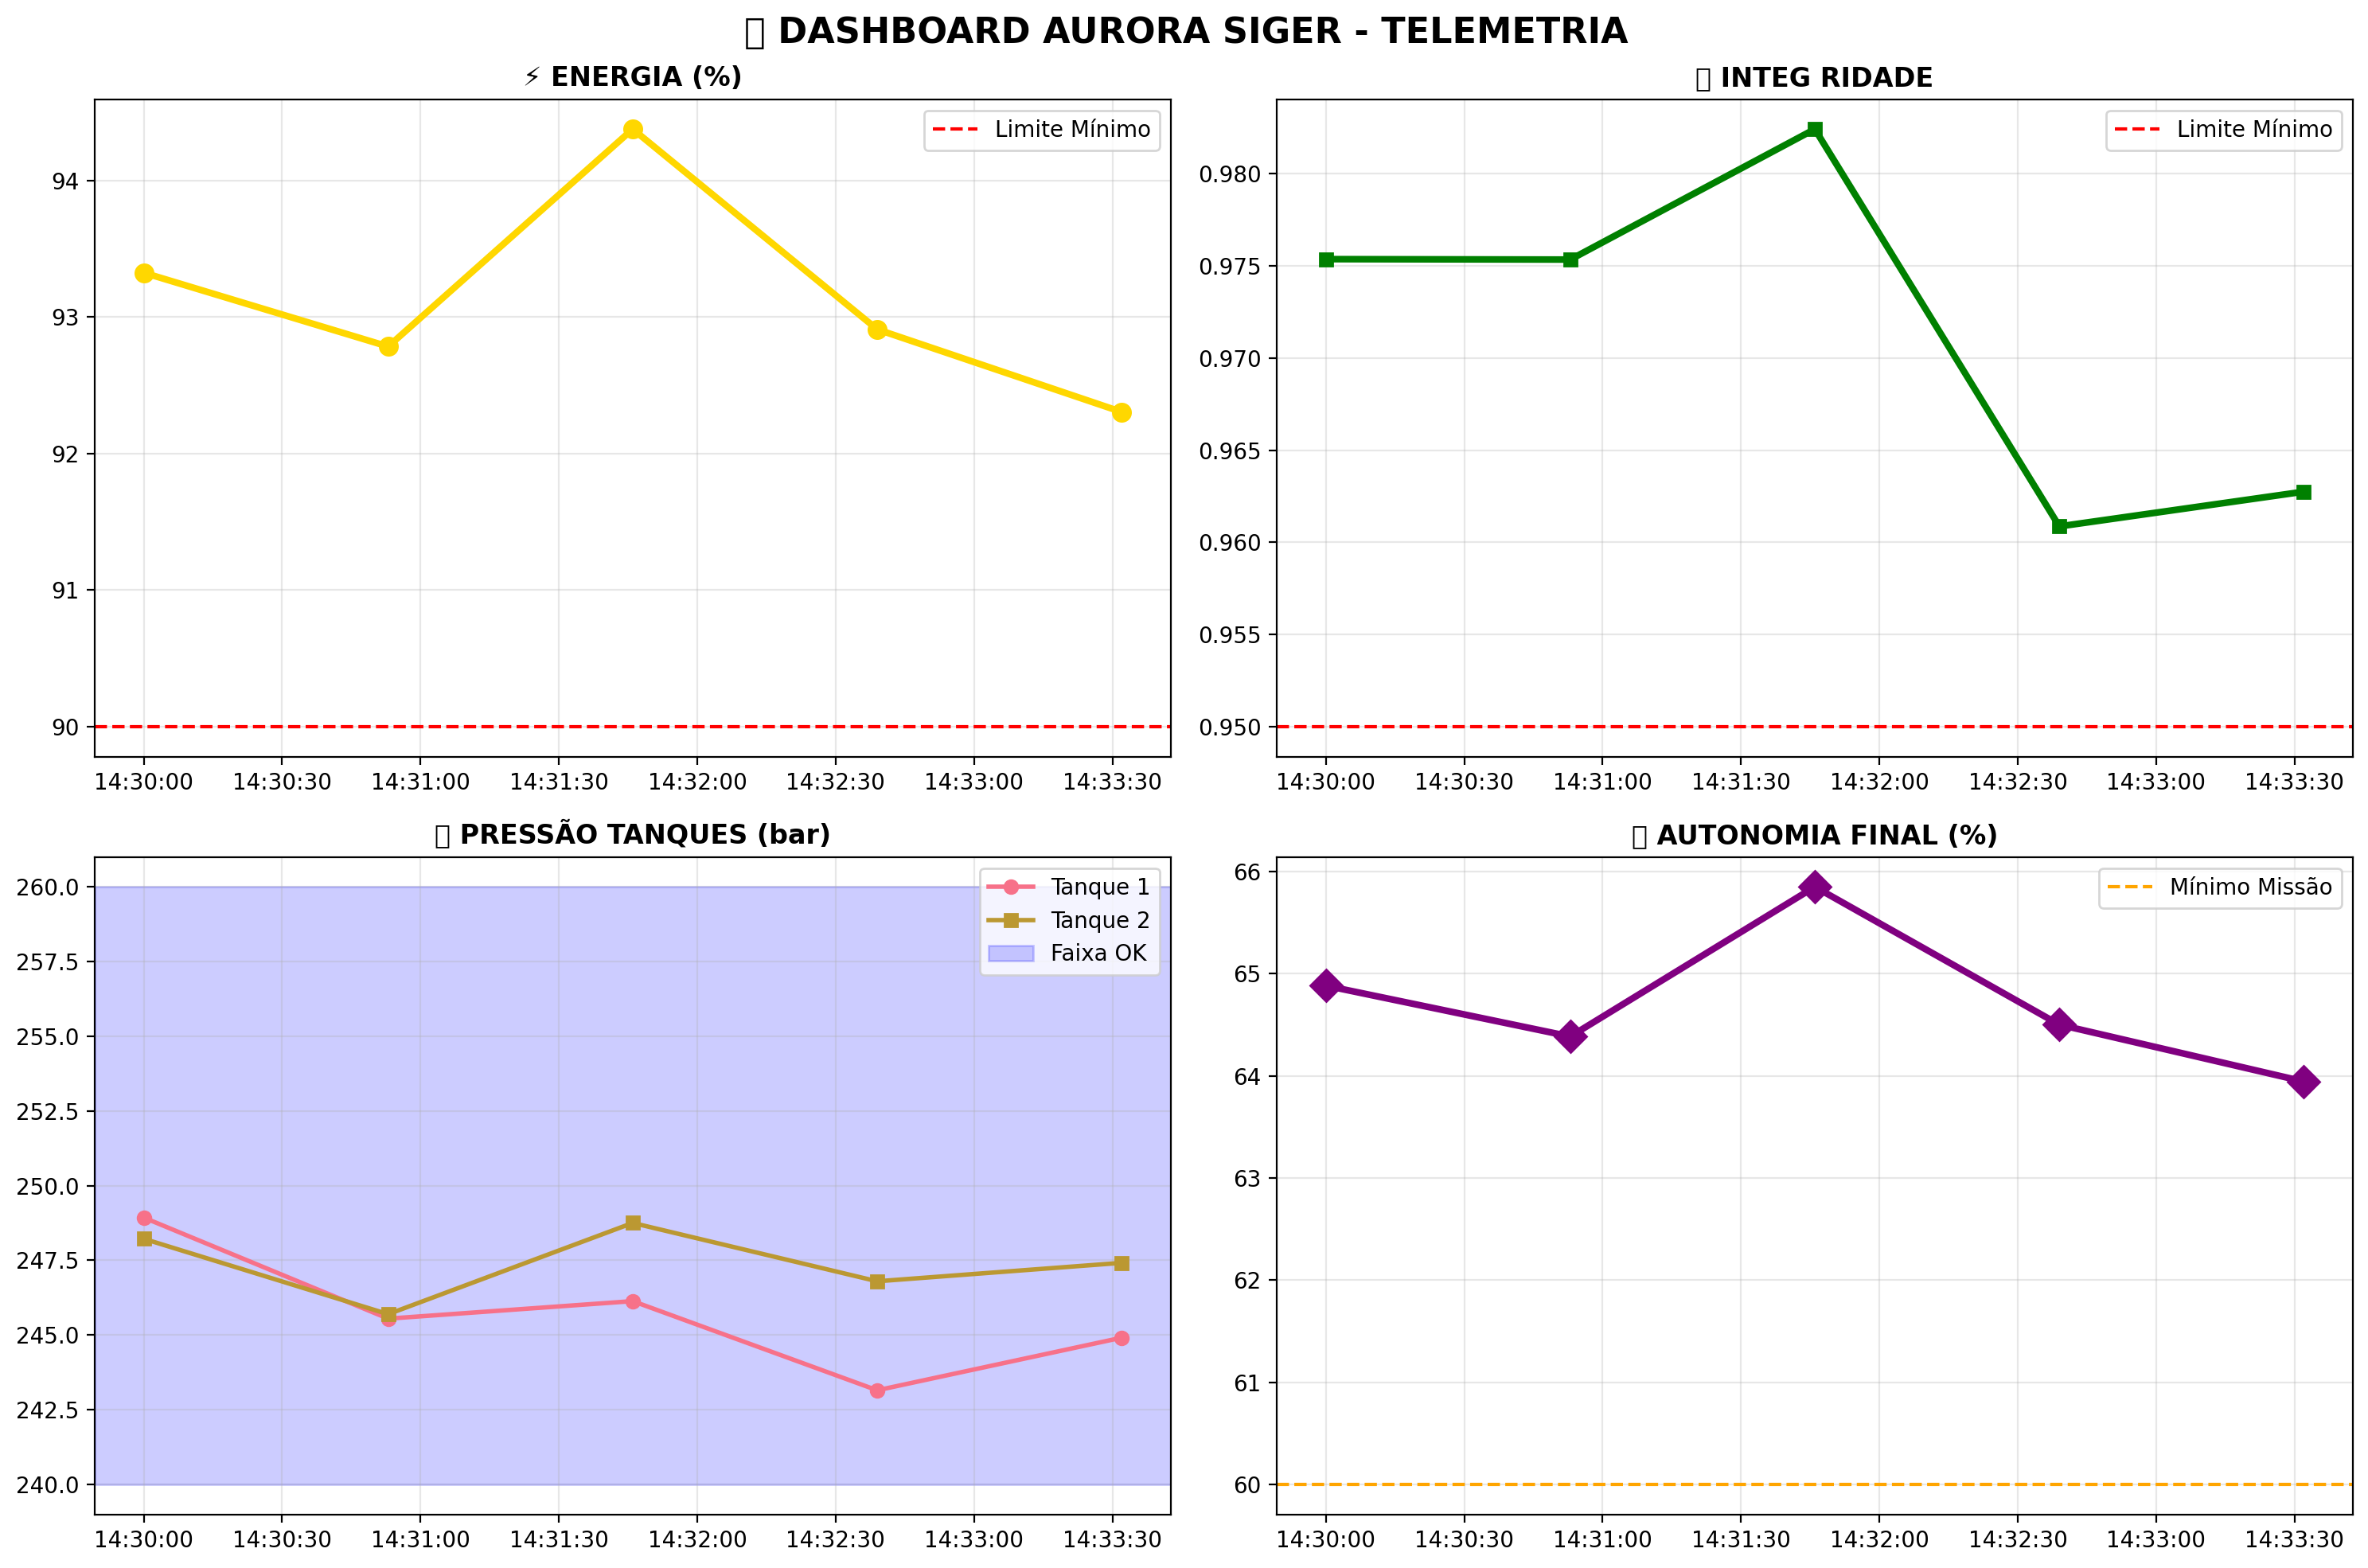

In [7]:
# =============================================================================
# 4. VISUALIZAÇÕES - GRÁFICOS
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('🚀 DASHBOARD AURORA SIGER - TELEMETRIA', fontsize=16, fontweight='bold')

# Gráfico 1: Energia
axes[0,0].plot(sistema.telemetria['timestamp'], sistema.telemetria['energia'],
               marker='o', linewidth=3, markersize=8, color='gold')
axes[0,0].axhline(y=90, color='red', linestyle='--', label='Limite Mínimo')
axes[0,0].set_title('⚡ ENERGIA (%)', fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Gráfico 2: Integridade
axes[0,1].plot(sistema.telemetria['timestamp'], sistema.telemetria['integridade'],
               marker='s', linewidth=3, color='green')
axes[0,1].axhline(y=0.95, color='red', linestyle='--', label='Limite Mínimo')
axes[0,1].set_title('🏗️ INTEG RIDADE', fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Gráfico 3: Pressão Tanques
axes[1,0].plot(sistema.telemetria['timestamp'], sistema.telemetria['pressao_tanque1'],
               marker='o', label='Tanque 1', linewidth=2)
axes[1,0].plot(sistema.telemetria['timestamp'], sistema.telemetria['pressao_tanque2'],
               marker='s', label='Tanque 2', linewidth=2)
axes[1,0].axhspan(240, 260, alpha=0.2, color='blue', label='Faixa OK')
axes[1,0].set_title('⛽ PRESSÃO TANQUES (bar)', fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Gráfico 4: Autonomia
axes[1,1].plot(energia_df['timestamp'], energia_df['autonomia_percent'],
               marker='D', linewidth=3, color='purple', markersize=10)
axes[1,1].axhline(y=60, color='orange', linestyle='--', label='Mínimo Missão')
axes[1,1].set_title('🔋 AUTONOMIA FINAL (%)', fontweight='bold')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ANÁLISE IA

CLASSIFICAÇÃO: NORMAL (Risco 1.2%)
ANOMALIAS: NENHUMA
## SUGESTÕES:
- Monitorar Tanque 2 (250.1 bar)
- Pré-aquecer propulsores T-5min